# Projet : Analyse spatiale des températures maximales en Île-de-France (Partie 2)

In [1]:
# Import des modules
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

Après avoir identifié les stations les plus chaudes, cette seconde partie vise à explorer des facteurs susceptibles d'expliquer les différences de température observées.

---

## 1. Hypothèses et choix des facteurs

Plusieurs facteurs peuvent influencer les températures observées, notamment la végétation, la densité urbaine ou encore la localisation des stations.

Dans ce projet, deux facteurs simples sont retenus :
* la densité de population
* la distance au centre de Paris

La densité de population est utilisée comme un indicateur du niveau d'urbanisation. Les zones denses correspondent généralement à des environnements plus construits et actifs, susceptibles de retenir davantage la chaleur.

La distance au centre de Paris est introduite comme un indicateur de position géographique au sein de l'Île-de-France. L'hypothèse est que les zones proches du centre, plus urbanisées et concentrant davantage d'activités humaines, pourraient présenter des températures plus élevées.

Ces variables sont choisies pour leur simplicité de construction et la disponibilité des données à l'échelle de l'Île-de-France et sur la période étudiée.

---

## 2. Données complémentaires

Les données utilisées proviennent du jeu de données 
[Communes et villes de France en CSV, Excel, Json, Parquet et Feather](https://www.data.gouv.fr/datasets/communes-et-villes-de-france-en-csv-excel-json-parquet-et-feather).

Ce jeu de données fournit des informations sur les communes françaises, notamment la population, la superficie et la densité de population. Dans le cadre de ce projet, seule la densité de population est utilisée.

Les données de 2025 sont utilisées.


### 2.1 Chargement et préparation des données

Les données sont importées puis vérifiées rapidement.  
Elles sont filtrées afin de ne conserver que les communes d'Île-de-France, et seules les colonnes utiles sont conservées.  
Un nettoyage léger est effectué afin de supprimer les valeurs manquantes.

In [2]:
# Chargement des données
df_communes = pd.read_csv('../data/raw/communes-france-2025.csv')

C:\Users\dataa\AppData\Local\Temp\ipykernel_632\850710191.py:2: DtypeWarning: Columns (1,12,14,16,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_communes = pd.read_csv('../data/raw/communes-france-2025.csv')


In [3]:
# Vérification
print(df_communes.info(), "\n")
print('Dimensions : ', df_communes.shape, '\n')
df_communes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34935 entries, 0 to 34934
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         34935 non-null  int64  
 1   code_insee                         34935 non-null  object 
 2   nom_standard                       34935 non-null  object 
 3   nom_sans_pronom                    34935 non-null  object 
 4   nom_a                              34935 non-null  object 
 5   nom_de                             34935 non-null  object 
 6   nom_sans_accent                    34935 non-null  object 
 7   nom_standard_majuscule             34935 non-null  object 
 8   typecom                            34935 non-null  object 
 9   typecom_texte                      34935 non-null  object 
 10  reg_code                           34935 non-null  int64  
 11  reg_nom                            34935 non-null  obj

,Unnamed: 0,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
0,0,01001,L'Abergement-Clémenciat,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
1,1,01002,L'Abergement-de-Varey,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
2,2,01004,Ambérieu-en-Bugey,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...
3,3,01005,Ambérieux-en-Dombes,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,...,4.903,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...
4,4,01006,Ambléon,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,...,5.601,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon


In [4]:
# Filtrage des communes d'Île-de-France
df_idf = df_communes[df_communes['reg_nom'] == 'Île-de-France']
# Vérification
print(df_idf.shape)
print(df_idf['reg_nom'].unique())

(1267, 47)
['Île-de-France']


In [5]:
# Sélection des colonnes utiles
df_idf = df_idf[['nom_standard', 'densite']]
# Vérification
display(df_idf.head())

,nom_standard,densite
29244,Paris,20238.0
29953,Achères-la-Forêt,92.0
29954,Amillis,40.0
29955,Amponville,29.0
29956,Andrezel,39.0


In [6]:
# Vérification des types
df_idf.dtypes

nom_standard     object
densite         float64
dtype: object

In [7]:
# Détecter les valeurs manquantes
df_idf.isna().sum()

nom_standard    0
densite         0
dtype: int64

### 2.2 Exploration rapide

In [8]:
display(df_idf.head())
df_idf.describe()

,nom_standard,densite
29244,Paris,20238.0
29953,Achères-la-Forêt,92.0
29954,Amillis,40.0
29955,Amponville,29.0
29956,Andrezel,39.0


,densite
count,1267.000000
mean,1461.317285
std,3255.349494
min,3.000000
25%,62.000000
50%,167.000000
75%,1063.500000
max,28220.000000


In [9]:
df_idf.sort_values('densite', ascending=False).head(10)

,nom_standard,densite
34518,Levallois-Perret,28220.0
34621,Vincennes,25549.0
34563,Le Pré-Saint-Gervais,24442.0
34609,Saint-Mandé,23550.0
34522,Montrouge,23023.0
34510,Clichy,21055.0
29244,Paris,20238.0
34512,Courbevoie,19595.0
34504,Boulogne-Billancourt,19481.0
34552,Les Lilas,18775.0


Les densités de population varient fortement entre les communes d'Île-de-France, allant de zones peu denses à des communes très urbaines.
Les valeurs les plus élevées correspondent par exemple à des communes comme Levallois-Perret ou Vincennes, illustrant cette hétérogénéité.
Cette variabilité rend cette variable pertinente pour explorer son lien avec les différences de température.


### 2.3 Sauvegarde des données

In [10]:
df_idf.to_csv("../data/processed/df_idf.csv", index=False)

---

## 3. Fusion avec les données des stations

### 3.1 Données des températures estivales

On charge les données de températures des stations météorologiques en Île-de-France (df_final_clean) issues de la partie 1.

In [11]:
df_final_clean = pd.read_csv("../data/processed/df_final_clean.csv")

In [12]:
# Vérification
print("Dimensions : ", df_final_clean.shape)
df_final_clean.head()

Dimensions :  (21804, 6)


,station,lat,lon,date,temp_max,departement
0,LUXEMBOURG,48.844833,2.3385,2025-01-01,9.0,75
1,LUXEMBOURG,48.844833,2.3385,2025-01-02,5.2,75
2,LUXEMBOURG,48.844833,2.3385,2025-01-03,5.5,75
3,LUXEMBOURG,48.844833,2.3385,2025-01-04,11.5,75
4,LUXEMBOURG,48.844833,2.3385,2025-01-05,13.2,75


On ne conserve que les températures estivales, comprises entre mai et septembre 2025, pour l'analyse statistique.

In [13]:
df_estival = df_final_clean[
    (df_final_clean['date'] >= "2025-05-01") & 
    (df_final_clean['date'] < "2025-10-01")
]

In [14]:
# Vérification 
print("Dimensions : ", df_estival.shape) 
df_estival.head()

Dimensions :  (7118, 6)


,station,lat,lon,date,temp_max,departement
120,LUXEMBOURG,48.844833,2.3385,2025-05-01,30.0,75
121,LUXEMBOURG,48.844833,2.3385,2025-05-02,29.7,75
122,LUXEMBOURG,48.844833,2.3385,2025-05-03,27.3,75
123,LUXEMBOURG,48.844833,2.3385,2025-05-04,19.3,75
124,LUXEMBOURG,48.844833,2.3385,2025-05-05,16.9,75


### 3.2 Associer chaque station à une commune

Les coordonnées des stations sont utilisées pour récupérer le nom de la commune associée via un service de géocodage inversé. Ce service permet de convertir une position géographique (latitude, longitude) en information administrative (commune).

In [15]:
# Création de l'outil de géocodage (connexion au service)
geolocator = Nominatim(user_agent='mon_projet_idf')

In [16]:
def get_commune(lat, lon):
    """
    Retourne le nom de la commune à partir de coordonnées GPS 
    via un service de géocodage inversé
    """
    # Appel au service : coordonnées -> adresse
    location = geolocator.reverse((lat, lon), language='fr')
    # Vérifier qu'on a bien une réponse
    if location is None:
        return None
    # Récupérer le dictionnaire d'adresse
    address = location.raw['address']
    # Selon les cas, la commune peut être dans différents champs
    if 'city' in address:
        return address['city']
    elif 'town' in address:
        return address['town']
    elif 'village' in address:
        return address['village']
    else:
        return None

In [17]:
# Attribution des communes aux stations par géocodage inversé

# Dataframe des stations avec leurs coordonnées GPS (une ligne par station)
df_stations = df_estival[['station', 'lat', 'lon']].drop_duplicates()

# Liste pour stocker les communes récupérées
communes = []

# Parcours de chaque station
for _, row in df_stations.iterrows():
        # Appel de la fonction pour obtenir la commune
        commune = get_commune(row['lat'], row['lon'])
        # Ajout à la liste
        communes.append(commune)
        # Pause pour éviter la surcharge du service
        time.sleep(1)

# Ajout de la colonne commune au dataframe
df_stations['commune'] = communes

In [18]:
# Vérification
print("Nombre de communes :", df_stations['commune'].nunique())
df_stations.head()

Nombre de communes : 42


,station,lat,lon,commune
120,LUXEMBOURG,48.844833,2.338500,Paris
584,TOUR EIFFEL,48.858333,2.294500,Paris
1048,LARIBOISIERE,48.882833,2.352000,Paris
1512,PARIS-MONTSOURIS,48.821667,2.337833,Paris
1976,PARIS-MONTSOURIS-DOUBLE,48.821667,2.337833,Paris


### 3.3. Harmoniser les noms

Une vérification est effectuée pour s'assurer de la correspondance des communes entre les stations météorologiques et le jeu de données socio-démographique.

In [19]:
communes_stations = set(df_stations['commune'].unique())
communes_idf = set(df_idf['nom_standard'].unique())

print("Nombre de communes stations :", len(communes_stations))
print("Nombre de communes IDF :", len(communes_idf))
print("Communes en commun :", len(communes_stations & communes_idf))

Nombre de communes stations : 42
Nombre de communes IDF : 1263
Communes en commun : 42


Les stations météorologiques couvrent 42 communes, toutes présentes dans le jeu de données socio-démographique, aucune harmonisation supplémentaire n'est nécessaire.


### 3.4. Enrichissement des données de températures avec les communes

In [20]:
df_estival = df_estival.merge(df_stations[['station', 'commune']], on='station', how='left')

In [21]:
# Vérification 
print("Dimensions : ", df_estival.shape)
print("Nombre de communes manquantes :", df_estival['commune'].isna().sum())
df_estival.head()

Dimensions :  (7118, 7)
Nombre de communes manquantes : 0


,station,lat,lon,date,temp_max,departement,commune
0,LUXEMBOURG,48.844833,2.3385,2025-05-01,30.0,75,Paris
1,LUXEMBOURG,48.844833,2.3385,2025-05-02,29.7,75,Paris
2,LUXEMBOURG,48.844833,2.3385,2025-05-03,27.3,75,Paris
3,LUXEMBOURG,48.844833,2.3385,2025-05-04,19.3,75,Paris
4,LUXEMBOURG,48.844833,2.3385,2025-05-05,16.9,75,Paris


### 3.5 Enrichissement des données de températures avec les densités

In [22]:
df_estival = df_estival.merge(df_idf[['nom_standard', 'densite']], left_on='commune', right_on='nom_standard', how='left')

In [23]:
# Vérification
print("Dimensions : ", df_estival.shape)
print("Nombre de densités manquantes :", df_estival['densite'].isna().sum())
df_estival.head()

Dimensions :  (7118, 9)
Nombre de densités manquantes : 0


,station,lat,lon,date,temp_max,departement,commune,nom_standard,densite
0,LUXEMBOURG,48.844833,2.3385,2025-05-01,30.0,75,Paris,Paris,20238.0
1,LUXEMBOURG,48.844833,2.3385,2025-05-02,29.7,75,Paris,Paris,20238.0
2,LUXEMBOURG,48.844833,2.3385,2025-05-03,27.3,75,Paris,Paris,20238.0
3,LUXEMBOURG,48.844833,2.3385,2025-05-04,19.3,75,Paris,Paris,20238.0
4,LUXEMBOURG,48.844833,2.3385,2025-05-05,16.9,75,Paris,Paris,20238.0


In [24]:
# Supprimer la colonne nom_standard
df_estival = df_estival.drop(columns=['nom_standard'])

In [25]:
# Vérification
df_estival.head()

,station,lat,lon,date,temp_max,departement,commune,densite
0,LUXEMBOURG,48.844833,2.3385,2025-05-01,30.0,75,Paris,20238.0
1,LUXEMBOURG,48.844833,2.3385,2025-05-02,29.7,75,Paris,20238.0
2,LUXEMBOURG,48.844833,2.3385,2025-05-03,27.3,75,Paris,20238.0
3,LUXEMBOURG,48.844833,2.3385,2025-05-04,19.3,75,Paris,20238.0
4,LUXEMBOURG,48.844833,2.3385,2025-05-05,16.9,75,Paris,20238.0


### 3.6. Ajouter la distance au centre de Paris

La distance de chaque station au centre de Paris est calculée afin d'analyser l'influence de la localisation géographique sur les températures.

In [26]:
# Coordonnées du centre de Paris
paris = (48.8566, 2.3522)

# Fonction qui calcule la distance entre une station et Paris
def compute_distance(row):
    return geodesic(paris, (row['lat'], row['lon'])).km

# Application de la fonction à chaque ligne du dataframe
df_estival['distance_paris'] = df_estival.apply(compute_distance, axis=1)

In [27]:
# Vérification
df_estival.head()

,station,lat,lon,date,temp_max,departement,commune,densite,distance_paris
0,LUXEMBOURG,48.844833,2.3385,2025-05-01,30.0,75,Paris,20238.0,1.650236
1,LUXEMBOURG,48.844833,2.3385,2025-05-02,29.7,75,Paris,20238.0,1.650236
2,LUXEMBOURG,48.844833,2.3385,2025-05-03,27.3,75,Paris,20238.0,1.650236
3,LUXEMBOURG,48.844833,2.3385,2025-05-04,19.3,75,Paris,20238.0,1.650236
4,LUXEMBOURG,48.844833,2.3385,2025-05-05,16.9,75,Paris,20238.0,1.650236


---

## 4. Analyse statistique des températures


L'objectif de cette partie est d'étudier les facteurs susceptibles d'expliquer les variations de température observées entre les stations, notamment la densité de population et la distance au centre de Paris.

L'analyse repose dans un premier temps sur des méthodes exploratoires (corrélations), puis sur un modèle de régression linéaire multiple permettant de tester l'existence d'une relation linéaire entre ces variables et la température.


### 4.1 Visualisation des relations entre variables

#### Température vs densité

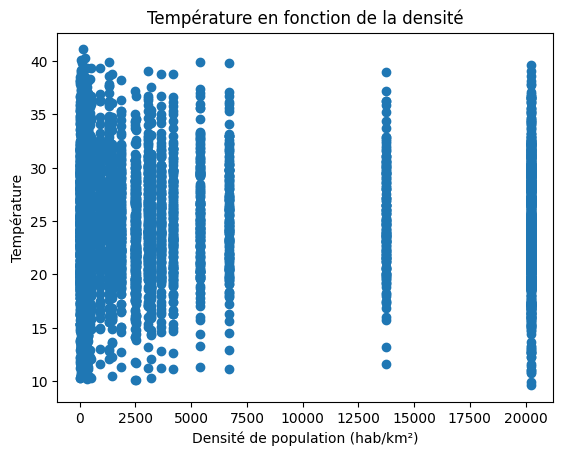

In [28]:
plt.figure()
plt.scatter(df_estival['densite'], df_estival['temp_max'])
plt.xlabel("Densité de population (hab/km²)")
plt.ylabel("Température")
plt.title("Température en fonction de la densité")
plt.show()

Le graphique présente des regroupements verticaux pour certaines valeurs de densité.  
Aucune relation claire entre densité et température ne se dégage à ce stade.

#### Température vs distance à Paris

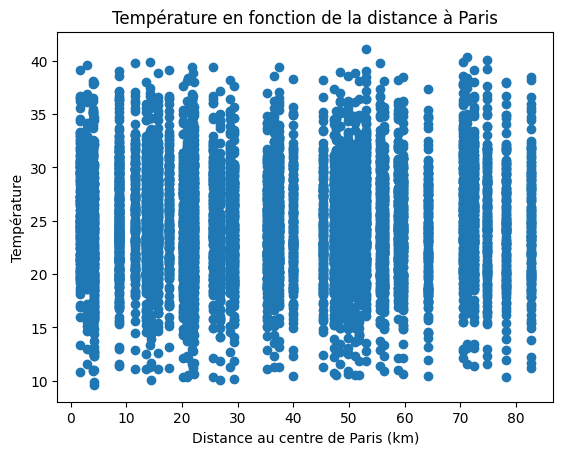

In [29]:
plt.figure()
plt.scatter(df_estival['distance_paris'], df_estival['temp_max'])
plt.xlabel("Distance au centre de Paris (km)")
plt.ylabel("Température")
plt.title("Température en fonction de la distance à Paris")
plt.show()

On observe également des alignements verticaux pour différentes distances.  
Aucune tendance nette entre distance et température n'apparaît.

#### Visualisation combinée

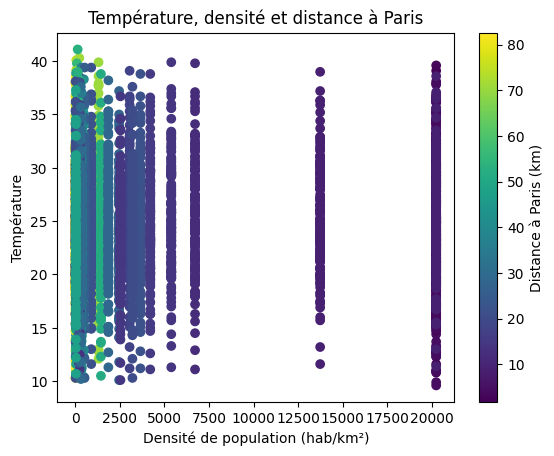

In [30]:
plt.figure()
plt.scatter(
    df_estival['densite'],
    df_estival['temp_max'],
    c=df_estival['distance_paris'])
plt.xlabel("Densité de population (hab/km²)")
plt.ylabel("Température")
plt.title("Température, densité et distance à Paris")
plt.colorbar(label="Distance à Paris (km)")
plt.show()

La visualisation combinée ne permet pas d'identifier de structure supplémentaire. Elle confirme visuellement l’absence de relation forte entre les variables étudiées.

#### Analyse globale

Les visualisations précédentes montrent des structures en alignements verticaux, qui s'expliquent par la structure du jeu de données : chaque station est observée à plusieurs dates, ce qui génère des répétitions de certaines variables explicatives (densité et distance).

Ces répétitions introduisent un biais visuel dans l'analyse graphique et limitent l'interprétation directe des relations entre variables.

#### Ajustement des données 

Afin de corriger ce biais, les données sont agrégées au niveau des stations en calculant la température moyenne.

In [31]:
df_station_mean = df_estival.groupby('station').agg({
    'temp_max': 'mean',
    'densite': 'first',
    'distance_paris': 'first'
}).reset_index()

In [32]:
# Vérification
print("Dimensions :", df_station_mean.shape)
df_station_mean.head()

Dimensions : (47, 4)


,station,temp_max,densite,distance_paris
0,ACHERES,25.170588,898.0,21.747246
1,BRETIGNY_SAPC,24.663399,1857.0,28.544618
2,CHANGIS,25.036601,200.0,49.823767
3,CHEVRU,23.635294,75.0,64.181200
4,COURDIMANCHE,24.756209,48.0,48.374791


L'agrégation au niveau des stations conduit à un nombre limité d'observations. Ce choix est néanmoins nécessaire afin de conserver une unité d'analyse cohérente et d'éviter les biais liés aux répétitions temporelles.

#### Visualisation des données ajustées

##### Température vs densité

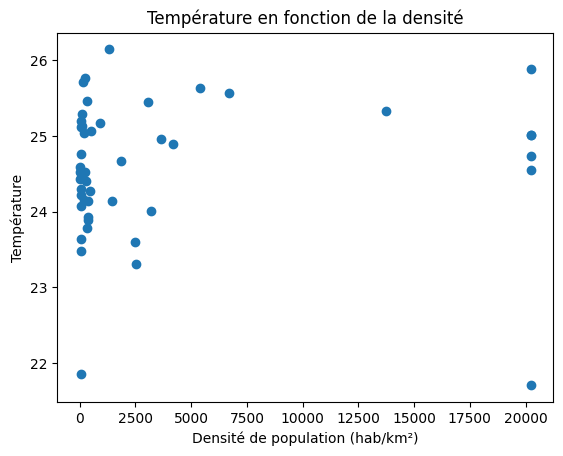

In [33]:
plt.figure()
plt.scatter(df_station_mean['densite'], df_station_mean['temp_max'])
plt.xlabel("Densité de population (hab/km²)")
plt.ylabel("Température")
plt.title("Température en fonction de la densité")
plt.show()

Le nuage de points est constitué d'un nombre limité d'observations, ce qui rend l'interprétation délicate.

La majorité des stations se situe autour de températures supérieures à 23°C et de densités supérieures à 6000 hab/km². Quelques observations isolées apparaissent pour des densités extrêmes.

Aucune relation claire entre la densité de population et la température ne se dégage.


#### Température vs distance à Paris

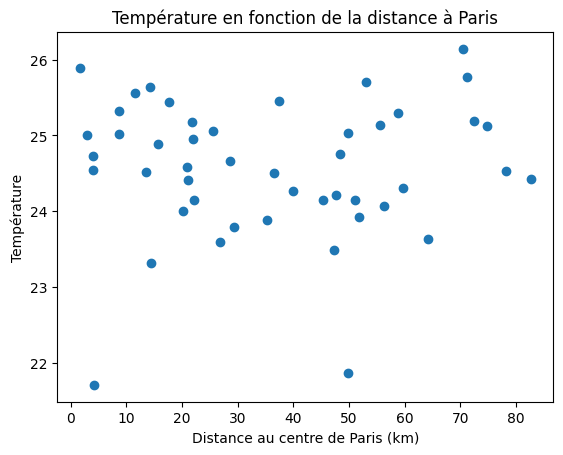

In [34]:
plt.figure()
plt.scatter(df_station_mean['distance_paris'], df_station_mean['temp_max'])
plt.xlabel("Distance au centre de Paris (km)")
plt.ylabel("Température")
plt.title("Température en fonction de la distance à Paris")
plt.show()

Les observations sont relativement dispersées sur l'ensemble des distances à Paris.  
La majorité des stations présente des températures supérieures à 23°C, sans structure claire selon la distance.  
Deux observations isolées apparaissent pour des températures plus faibles, mais elles ne suffisent pas à suggérer une tendance.   Aucune relation évidente entre distance et température ne peut être mise en évidence.


#### Visualisation combinée

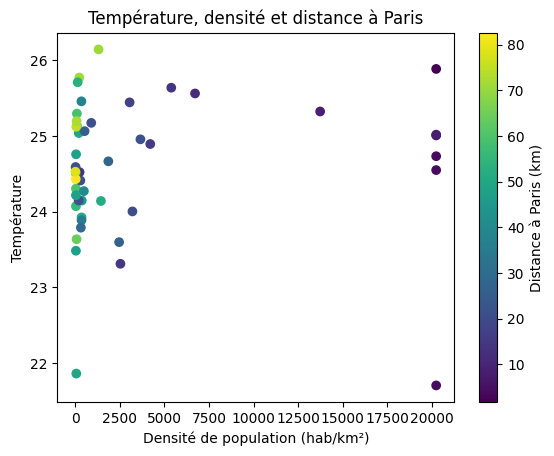

In [35]:
plt.figure()
plt.scatter(
    df_station_mean['densite'],
    df_station_mean['temp_max'],
    c=df_station_mean['distance_paris'])
plt.xlabel("Densité de population (hab/km²)")
plt.ylabel("Température")
plt.title("Température, densité et distance à Paris")
plt.colorbar(label="Distance à Paris (km)")
plt.show()

La visualisation combinée ne met pas en évidence de relation claire entre la température et les variables étudiées.  
On observe toutefois que les communes les plus denses sont généralement situées à proximité de Paris, tandis que les communes moins denses sont plus souvent éloignées.    
Cependant, cette structure entre densité et distance ne semble pas associée à des variations marquées de température.

### 4.2 Corrélation

Cette étape vise à quantifier les relations linéaires entre la température et les variables explicatives, à savoir la densité de population et la distance au centre de Paris.

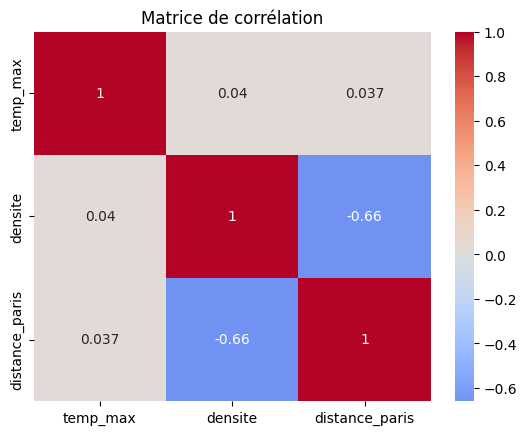

In [36]:
corr = df_station_mean[['temp_max', 'densite', 'distance_paris']].corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.show()

Les coefficients de corrélation entre la température et les variables explicatives sont très faibles (proches de 0).  
Cela indique l'absence de relation linéaire significative entre la température et la densité de population, ainsi qu'entre la température et la distance au centre de Paris.  
Ces résultats confirment les observations issues de l'analyse graphique.


### 4.3 Régression linéaire

On cherche à évaluer si la densité de population et la distance à Paris permettent d'expliquer les variations de température estivale.

#### Préparation des données

In [37]:
# Variables explicatives
X = df_station_mean[['densite', 'distance_paris']]
# Variable cible
y = df_station_mean['temp_max']

In [38]:
# Vérification des dimensions
print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)

Dimensions X : (47, 2)
Dimensions y : (47,)


#### Modélisation

In [44]:
# Initialisation du modèle
model = LinearRegression()
# Ajustement
model.fit(X, y)

LinearRegression()

#### Coefficients

In [45]:
print("Intercept :", model.intercept_)
print("Coefficient densité :", model.coef_[0])
print("Coefficient distance :", model.coef_[1])

Intercept : 24.360053241218626
Coefficient densité : 1.5063012184385562e-05
Coefficient distance : 0.004335268888079473


Les coefficients du modèle indiquent comment la température varie lorsque l'une des variables explicatives augmente, les autres restant inchangées.

Par exemple, si le coefficient associé à la densité était égal à 2, cela signifierait qu'une augmentation de la densité d'une unité entraînerait en moyenne une hausse de 2 degrés de la température.

Dans notre cas, les coefficients estimés sont proches de zéro, ce qui signifie que faire varier la densité de population ou la distance à Paris n'entraîne pas de variation notable de la température dans ce modèle.

Aucune relation linéaire simple entre les variables étudiées et la température n'est mise en évidence.


#### Qualité globale du modèle

In [46]:
r2 = model.score(X, y)
print("R² :", r2)

R² : 0.008667866301354965


Le coefficient de détermination (R²) mesure la part de la variabilité de la température que le modèle parvient à expliquer. 
Autrement dit, il indique dans quelle mesure les variations de température sont reproduites par le modèle.

Le coefficient de détermination R² est très faible, indiquant que le modèle ne reproduit qu'une faible part de la variabilité des températures.

#### Analyse des résidus

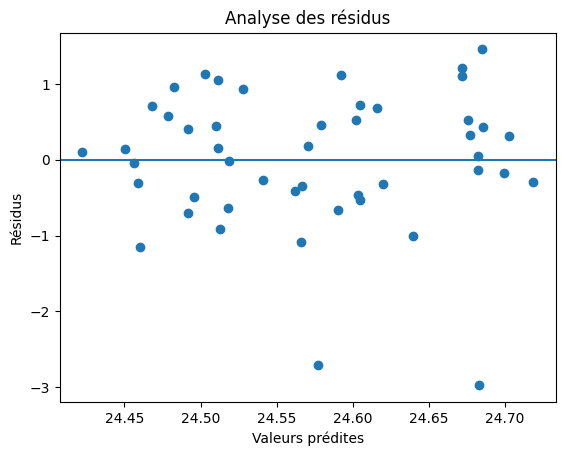

In [47]:
y_pred = model.predict(X)
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Analyse des résidus")
plt.show()

Les résidus correspondent aux écarts entre les valeurs observées et les valeurs prédites par le modèle.
Ils représentent la part de la variabilité de la température non expliquée par les variables explicatives.

Leur analyse permet de vérifier si une structure systématique subsiste dans les erreurs du modèle.

Dans notre cas, les résidus sont répartis de manière aléatoire autour de zéro, sans structure visible, et leur dispersion apparaît globalement homogène sur l'ensemble des valeurs prédites.


### 4.4 Conclusion de l’analyse statistique

L'analyse exploratoire (visualisations et corrélations) ainsi que la régression linéaire ne mettent pas en évidence de relation linéaire claire entre la température estivale et les variables explicatives étudiées (densité de population et distance à Paris).

Les coefficients estimés sont proches de zéro, ce qui indique l'absence d'effet linéaire détectable de ces variables dans le modèle.

Le pouvoir explicatif du modèle est très faible (R² proche de 0), ce qui signifie que les variations de température ne sont que très peu reproduites par ce modèle linéaire.

Les résidus sont répartis de manière aléatoire autour de zéro, sans motif visible, ce qui suggère que le modèle linéaire ne laisse pas apparaître de relation simple non captée dans les données.

Dans ce contexte, il n'est pas possible de conclure si cette absence de relation provient des variables choisies ou de la forme du modèle. D'autres facteurs ou des relations plus complexes pourraient être nécessaires pour expliquer les variations de température.

---

## Conclusion générale

L'analyse exploratoire a permis de mettre en évidence l'existence de variations spatiales de température en Île-de-France, avec certaines zones apparaissant plus chaudes que d'autres.

Afin d'expliquer ces différences, une analyse statistique a été menée en mobilisant deux variables explicatives : la densité de population et la distance au centre de Paris, à partir des données disponibles aux stations.

Les résultats ne mettent pas en évidence de relation linéaire exploitable entre ces variables et la température.

Ces résultats doivent toutefois être interprétés avec prudence, en raison du nombre limité d'observations, du choix restreint de variables explicatives et de l'utilisation d'un modèle linéaire simple.

Ils suggèrent que la compréhension des variations de température pourrait nécessiter, même à partir de ces mêmes points de mesure, l'intégration de variables plus pertinentes (par exemple la végétation, le type de sol ou la proximité de zones d'eau), ainsi que l'exploration de modèles plus adaptés à des relations potentiellement non linéaires.